# Getting Started with Neural‑LAM (DANRA)

This notebook provides end‑to‑end tutorial that walks through installing the library, loading data, creating the graph, training a model, and evaluating predictions.(In 30 min)

## Installation 

In [13]:
import os, sys
from pathlib import Path

root = Path(os.getcwd()).resolve()
while root.name and not (root / 'pyproject.toml').exists():
    root = root.parent

os.chdir(root)
!{sys.executable} -m pip install -e "{root}"


Project root found at: /home/sharkyi/neural-lam
Obtaining file:///home/sharkyi/neural-lam
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for neural-lam (pyproject.toml) ... done
  Created wheel for neural-lam: filename=neural_lam-0.1.dev86+g8d2f32c.d20260304-py3-none-any.whl size=12935 sha256=31beed0fe7aee363746586a4dd79ffe12e3d8ab1dbab6589e57563154307163d
  Stored in directory: /tmp/pip-ephem-wheel-cache-pey3vn31/wheels/db/47/99/d8239484455e098b048c998f1f8105aad7563c13f1135c4548
Successfully built neural-lam
  Attempting uninstall: neural-lam
    Found existing installation: neural-lam 0.1.dev86+g8d2f32c.d20260302
    Uninstalling neural-lam-0.1.dev86+g8d2f32c.d20260302:
      Successfully uninstalled neural-lam-0.1.dev86+g8d2f32c.d20260302


## Dataset: DANRA (Nordic Subset)
We use a small subset of the DANRA (Danish Regional Reanalysis) dataset:

Predicts: Temperature, winds, and humidity.
Inputs: Radiation and geographic features (elevation/land mask).
Grid: Focused on Denmark with 7,680 grid points.


## It covers:

1. Data preprocessing
2. Graph generation
3. Training for 1 epoch
4. Evaluation

## Load configuration and datastore

We use the helper `load_config_and_datastore` which reads the YAML config and prepares the `Datastore` object.


In [14]:
from neural_lam.config import load_config_and_datastore

config_path = Path('/home/sharkyi/neural-lam/data/config.yaml').resolve()
print('Loading config from', config_path)
config, datastore = load_config_and_datastore(config_path=str(config_path))

print('Datastore root:', datastore.root_path)
print('Number of grid points:', datastore.grid_shape_state.x * datastore.grid_shape_state.y)


/home/sharkyi/neural-lam/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-04 12:18:12.721 | WARNING  | neural_lam.datastore.mdp:__init__:65 - Config file has been modified since zarr was created. The old zarr archive (in /home/sharkyi/neural-lam/data/danra.datastore.zarr) will be used.To generate new zarr-archive, move the old one first.


Loading config from /home/sharkyi/neural-lam/data/config.yaml
The loaded datastore contains the following features:
 state   : u100m v100m r2m t2m
 forcing : swavr0m
 static  : lsm orography
With the following splits (over time):
 train   : 2022-04-01T00:00 to 2022-04-04T00:00
 val     : 2022-04-04T00:00 to 2022-04-07T00:00
 test    : 2022-04-07T00:00 to 2022-04-10T00:00
Datastore root: /home/sharkyi/neural-lam/data
Number of grid points: 7680


## Lets visualise temperature fields and compute basic statistics.


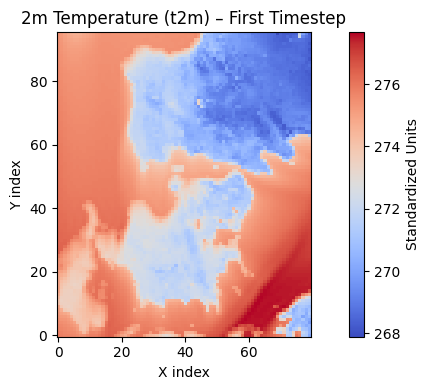

Temperature stats:
 mean = 273.4856
 std  = 2.5551
 min  = 267.8927
 max  = 277.6603


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Load the "state" variable from the training split
da = datastore.get_dataarray("state", "train")

# Select the first timestep and extract 2m temperature (t2m)
first_timestep = da.isel(time=0)
t2m = first_timestep.sel(state_feature="t2m")

# Convert the flattened grid into a 2D spatial grid
t2m_unstacked = datastore.unstack_grid_coords(t2m)
temp_2d = t2m_unstacked.compute().values

# Plot the temperature field
plt.figure(figsize=(8,4))
im = plt.imshow(temp_2d, cmap='coolwarm', origin='lower')
plt.title('2m Temperature (t2m) – First Timestep')
plt.colorbar(im, label='Standardized Units')
plt.xlabel('X index')
plt.ylabel('Y index')
plt.tight_layout()
plt.show()


print("Temperature stats:")
print(f" mean = {np.mean(temp_2d):.4f}")
print(f" std  = {np.std(temp_2d):.4f}")
print(f" min  = {np.min(temp_2d):.4f}")
print(f" max  = {np.max(temp_2d):.4f}")

## Graph Creation

We generate the graph using the existing utility and visualise node positions and a sampled set of edges.


2026-03-04 14:34:37.548 | WARNING  | neural_lam.datastore.mdp:__init__:65 - Config file has been modified since zarr was created. The old zarr archive (in /home/sharkyi/neural-lam/data/danra.datastore.zarr) will be used.To generate new zarr-archive, move the old one first.


The loaded datastore contains the following features:
 state   : u100m v100m r2m t2m
 forcing : swavr0m
 static  : lsm orography
With the following splits (over time):
 train   : 2022-04-01T00:00 to 2022-04-04T00:00
 val     : 2022-04-04T00:00 to 2022-04-07T00:00
 test    : 2022-04-07T00:00 to 2022-04-10T00:00


(<Figure size 1600x1600 with 2 Axes>,
 <Axes: title={'center': 'Mesh Graph (L1)'}>)

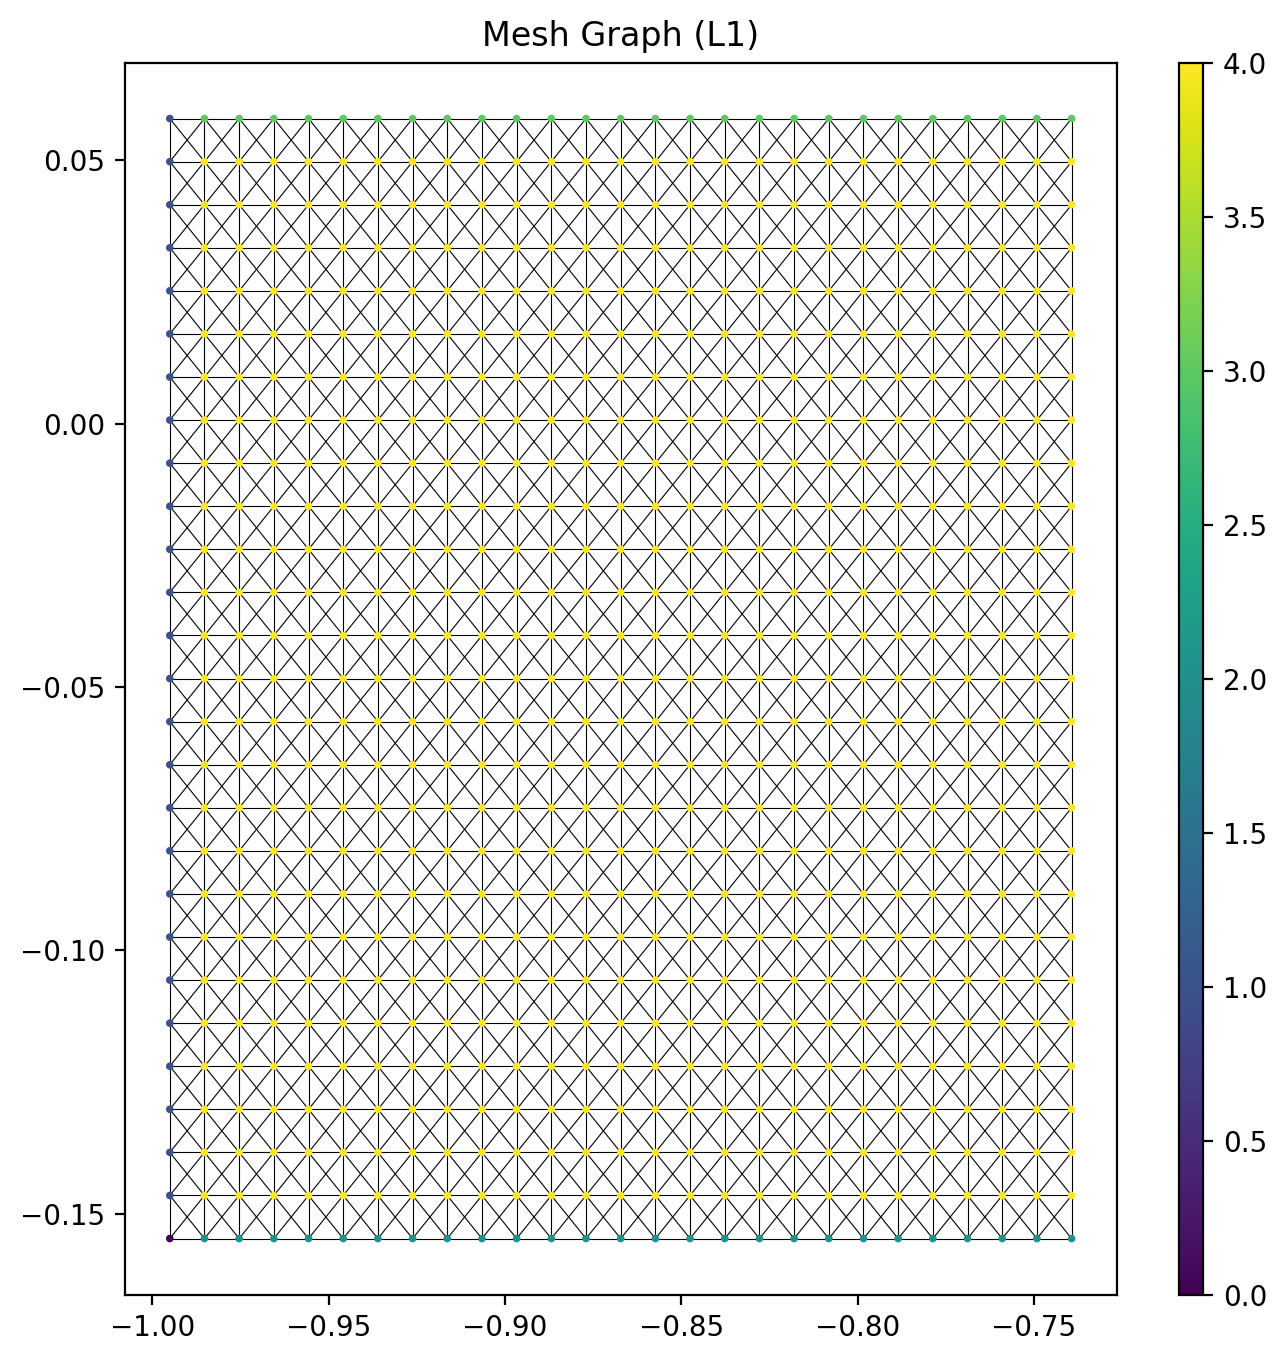

In [3]:
import os
from pathlib import Path
from torch_geometric.data import Data
from neural_lam import utils
from neural_lam import create_graph as cg
from neural_lam.config import load_config_and_datastore

# 1. Setup paths and load datastore
root = Path(os.getcwd()).resolve()
while root.name and not (root / 'pyproject.toml').exists():
    root = root.parent

config_path = root / 'data' / 'config.yaml'
config, datastore = load_config_and_datastore(config_path=str(config_path))

# 2. Load the graph data
graph_dir = os.path.join(datastore.root_path, 'graph', 'tutorial_graph')
hierarchical, graph_data = utils.load_graph(graph_dir)

# 3. Robustly select the mesh graph (L1)
if hierarchical:
    # In hierarchical mode, these are BufferLists/lists of tensors
    edge_index = graph_data['m2m_edge_index'][0]
    pos = graph_data['mesh_static_features'][0]
else:
    # In non-hierarchical mode, load_graph already extracts the first level
    edge_index = graph_data['m2m_edge_index']
    pos = graph_data['mesh_static_features']

# 4. Construct Data object and plot
mesh_l1 = Data(edge_index=edge_index, pos=pos)
cg.plot_graph(mesh_l1, title='Mesh Graph (L1)')


## Training with Real‑time Progress & Resource Tracking

We train a tiny model for a single epoch

In [ ]:
from neural_lam.models.graph_lam import GraphLAM
from neural_lam.weather_dataset import WeatherDataModule
import pytorch_lightning as pl
from argparse import Namespace

# Standard data module
data_module = WeatherDataModule(datastore=datastore, ar_steps_train=1, ar_steps_eval=1)

# Standard model 
args = Namespace(model='graph_lam', graph='tutorial_graph', hidden_dim=32, 
                 hidden_layers=1, processor_layers=2, mesh_aggr='sum', 
                 output_std=False, lr=1e-3, loss='mse', ar_steps_train=1)
model = GraphLAM(args, config=config, datastore=datastore)

# Standard Lightning Trainer
trainer = pl.Trainer(max_epochs=1, limit_train_batches=2, accelerator='cpu')
trainer.fit(model, datamodule=data_module)


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
/home/sharkyi/neural-lam/venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Loaded graph with 8409 nodes (7680 grid, 729 mesh)
Edges in subgraphs: m2m=5512, g2m=12716, m2g=30720
Starting training...


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ grid_embedder     │ Sequential        │  1.6 K │ train │     0 │
│ 1 │ g2m_embedder      │ Sequential        │  1.2 K │ train │     0 │
│ 2 │ m2g_embedder      │ Sequential        │  1.2 K │ train │     0 │
│ 3 │ g2m_gnn           │ InteractionNet    │  7.4 K │ train │     0 │
│ 4 │ encoding_grid_mlp │ Sequential        │  2.2 K │ train │     0 │
│ 5 │ m2g_gnn           │ InteractionNet    │  7.4 K │ train │     0 │
│ 6 │ output_map        │ Sequential        │  1.2 K │ train │     0 │
│ 7 │ mesh_embedder     │ Sequential        │  1.2 K │ train │     0 │
│ 8 │ m2m_embedder      │ Sequential        │  1.2 K │ train │     0 │
│ 9 │ processor         │ Sequential_0b596b │ 14.8 K │ train │     0 │
└───┴───────────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 39.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 39.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 83                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/sharkyi/neural-lam/venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/sharkyi/neural-lam/venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


/home/sharkyi/neural-lam/venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

⚡ Epoch 1: CPU 3.8% | MEM 66.7%

`Trainer.fit` stopped: `max_epochs=1` reached.


Training finished.


## Evaluation – Prediction vs Ground Truth

We load a validation sample, run the model, and visualise the initial state, prediction and ground truth side‑by‑side.


/home/sharkyi/neural-lam/venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


## Error Maps (MAE & RMSE)

We compute point‑wise absolute and squared errors and visualise them.


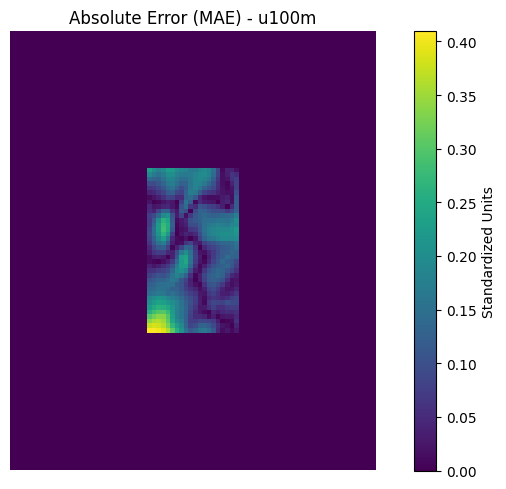

Overall RMSE for u100m: 0.0417


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# (.values converts the xarray DataArray into a numpy matrix)
pred_np = plt_pred.values
true_np = plt_true.values

# 2. Compute errors
error = np.abs(pred_np - true_np)
rmse = np.sqrt(((pred_np - true_np) ** 2).mean())

# 3. Plot
plt.figure(figsize=(8, 5))
im = plt.imshow(error, cmap='viridis', origin='lower')
plt.title(f'Absolute Error (MAE) - {feature_name}')
plt.colorbar(im, label='Standardized Units')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Overall RMSE for {feature_name}: {rmse:.4f}')
